In [1]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from cnn import ConvolutionalNeuralNetwork, Slicer, Reshape, Permute
import torch.nn as nn
import numpy as np
import pandas as pd


# Importing training data

The model BoundingBoxEnginnering transformer is going to produce a vector of shape (N, 5, 128, 128, 13). We've simulated the execution of the transformer and saved the file. Refer to [extract-training-data.ipynb](https://github.com/RobertDeLaCruzNEU/CS7180-Final/blob/main/notebooks/eda/example-extracting-bounding-boxes.ipynb) for more information about how the transformation happens. We'll import the .dat file with the simulated output.

Our .dat file include the bounding box images and the and additional metadata in the channels. We want to consume this information in the CNN and propogate it to the next model. To that end we separate the image data and the behavior we plan to model. Where "X" will hold the bounding box images + the category of the subject (predicted in the BoundingBoxEngineering class). "Y" will hold the 3 categorical values we plan to predict including the tranffic light state, pedestrian crossing, and pedestrian looking.

In [2]:
path = 'C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/annotations/vectorized-video-frames-labelled.dat'
data = np.memmap(path, dtype='float16', mode='r', shape=(3810, 5, 128, 128, 13))

X = data[:, :, :, :, :8]   # Shape (N, 5, 128, 128, 4), where 4 is the 3 color channels + the cls pedestrian or traffic light
y = data[:, :, 0, 0, 8:12] # Shape (N, 5, 5*), where 5* is the 4 of behavioural features + 5th is GPS speed
y = data[:, :, 0, 0, [8,10,11]] # Shape (N, 5, 5*), where 5* is the 4 of behavioural features + 5th is GPS speed

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Building the CNN
This architecture follows a classic "LeNet" or "AlexNet" style pattern but adds custom data-shaping layers at the start and end. It treats each of the five bounding boxes as an individual image for feature extraction before regrouping them.

# Phase 1: Data Preparation (The Pre-processors)

Before the math starts, these layers translate your NumPy-style data into a format PyTorch understands.

* **Slicer:** Your input has 8 channels. This layer picks only the first 4 (RGB and one context flag) to feed into the convolutional filters.
* **Reshape (Input):** This collapses your $N$ samples and 5 bounding boxes into a single long list of images. It turns a 5D array into a 4D array of $(N \times 5, 128, 128, 4)$.
* **Permute:** NumPy stores images as `(Height, Width, Channels)`. PyTorch needs `(Channels, Height, Width)`. This layer swaps the axes so the filters can slide across the pixel grid.

# Phase 2: Feature Extraction (Convolutional Blocks)

The model uses three identical blocks to find patterns like edges, shapes, and pedestrian poses.

* **Conv2d Layers:** These use $3 \times 3$ filters to scan the image. They start with 32 filters and double the depth at each step (32, 64, 128). This allows the model to see simple lines in the first layer and complex objects in the last.
* **ReLU:** This activation function turns negative values to zero. It helps the model learn non-linear patterns without the math becoming too complex.
* **MaxPool2d:** This shrinks the spatial size by half ($128 \to 64 \to 32 \to 16$). It keeps only the strongest signal in each $2 \times 2$ square, which makes the model focus on the most important features.

# Phase 3: Decision Making (The Dense Head)

Once the images are tiny $16 \times 16$ grids with 128 channels, the model flattens them into a single line of numbers.

* **Flatten:** It converts the spatial grid into a 32,768-element vector.
* **Linear (512):** This fully connected layer acts as the "brain." It looks at all extracted features at once to determine intent.
* **Dropout (0.3):** This randomly shuts off 30% of the neurons during training. It stops the model from memorizing your specific training crops and forces it to learn general pedestrian behaviors.
* **Linear (3):** The final regression head. It produces 3 continuous numbers for each crop.

# Phase 4: Output Reconstruction

* **Reshape (Output):** This puts the "5" back into the sequence. It groups the individual box predictions back to the original frames. Your final output shape is $(N, 5, 3)$.
* **MSELoss:** Since you are predicting intent flags on a scale (like -1 to 3), the model calculates the Mean Squared Error. It penalizes large misses more heavily than small ones to stay as close to the actual flag as possible.


# Training Specs
The model runs for **100 epochs** with a learning rate of **0.001**. The `passthrough` parameter suggests you are keeping the remaining 4 channels of metadata from the original array to use later in your pipeline.

Does the drop in loss happen mostly in the first 20 epochs, or does it stay steady for the whole run?


In [ ]:


cnn_traffic_behaviour = ConvolutionalNeuralNetwork(
    layers=[
        # Get the first 4 channels (RGB + pedestrian/traffic light)
        Slicer((slice(None), slice(None), slice(None), slice(None), slice(0, 4))), 
        Reshape((-1, 128, 128, 4)), 
        Permute((0, 3, 1, 2)),

        # Layer 1: Input is (8, 128, 128)
        nn.Conv2d(4, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2), # Output: (32, 64, 64)

        # Layer 2
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2), # Output: (64, 32, 32)

        # Layer 3
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2), # Output: (128, 16, 16)

        # Layer 4: Flatten for the dense layers
        nn.Flatten(), # Output: 128 * 16 * 16 = 32768
        
        # Layer 5: Fully Connected
        nn.Linear(32768, 512),
        nn.ReLU(),
        nn.Dropout(0.3), # Prevent overfitting on small pedestrian crops

        # Layer 6: Regression Head
        nn.Linear(512, 3),

        Reshape((-1, 5, 3))
    ],
    epoch=100,
    learning_rate=0.0001,
    batch_size=100,
    criterion='MSELoss',
    passthrough=slice(4, 8)
)


cnn_traffic_behaviour.fit(X_train, y_train)

Training CNN: 100%|██████████| 100/100 [09:43<00:00,  5.84s/it, loss=0.0069]


,epoch,100
,learning_rate,0.0001
,layers,Sequential( ...): Reshape() )
,criterion,'MSELoss'
,optimizer,'Adam'
,batch_size,100
,minimum_change,0.0
,seed,0
,passthrough,"slice(4, 8, None)"


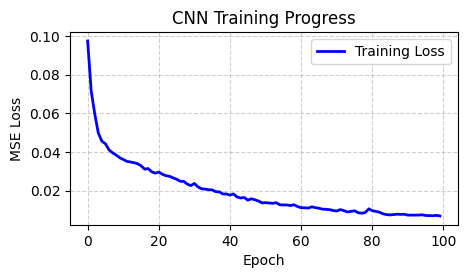

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 2.5))
plt.plot(cnn_traffic_behaviour.losses, label='Training Loss', color='blue', linewidth=2)
plt.title('CNN Training Progress')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
y_pred = cnn_traffic_behaviour.predict(X_test)

In [6]:
from sklearn.metrics import mean_absolute_error, accuracy_score, precision_score, recall_score

# Flatten both arrays to (N*5,3)
true_flat = y_test.reshape(-1, y_test.shape[-1])
pred_flat = y_pred.reshape(-1, y_pred.shape[-1])[:, 4:7]

results = []

labels  = ['Traffic light state','Pedestrian crossing', 'Pedestrian looking']
for label, i in zip(labels, range(3)):
    y_t = true_flat[:, i]
    y_p = pred_flat[:, i]
    
    # Round the raw regression output to the nearest flag integer
    y_p_rounded = np.round(y_p).astype(int)
    
    # Calculate scores
    mae = mean_absolute_error(y_t, y_p)
    acc = accuracy_score(y_t, y_p_rounded)
    prec = precision_score(y_t, y_p_rounded, average='macro', zero_division=0)
    rec = recall_score(y_t, y_p_rounded, average='macro', zero_division=0)
    results.append({
        "Flag": label,
        "Accuracy": f"{acc * 100:.1f}%",
        "Precision": round(prec, 4),
        "Recall": round(rec, 4)
    })

pd.DataFrame(results)

,Flag,Accuracy,Precision,Recall
0,Traffic light state,99.1%,0.8231,0.9761
1,Pedestrian crossing,98.3%,0.9759,0.7644
2,Pedestrian looking,97.7%,0.9494,0.7814


In [7]:
images = X_test[:, :, :, :, :4].reshape(-1, 128, 128, 4)
y_test_ = y_test.reshape(-1, 3)
y_pred_ = y_pred.reshape(-1, 3)

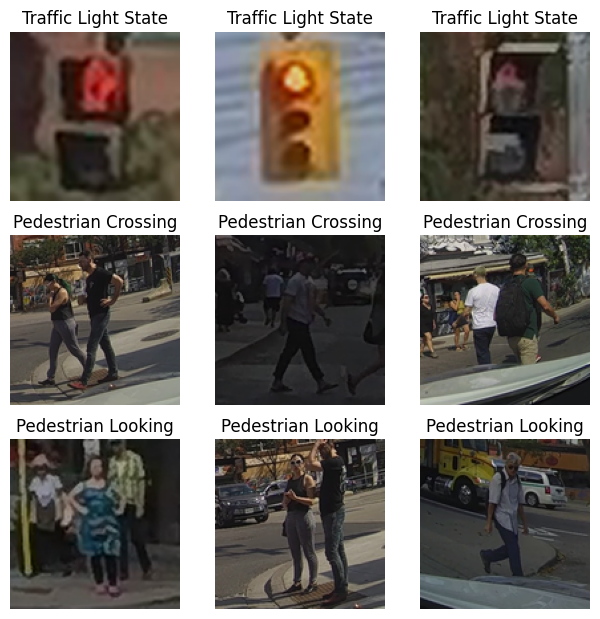

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

examples_pass = {'Traffic light state': [], 'Pedestrian crossing': [], 'Pedestrian looking': []}
for image, test, pred in zip(images, y_test_, y_pred_):
    if image[0, 0, 3] == -1 and test[0] == pred[0] and pred[0] != 0:  # Traffic light state
        examples_pass['Traffic light state'].append((image[:, :, :3] * 225).astype(np.uint8)) 
    if image[0, 0, 3] == 1 and test[1] == pred[1] and pred[1] != 0:  # Pedestrian crossing
        examples_pass['Pedestrian crossing'].append((image[:, :, :3] * 225).astype(np.uint8))
    if image[0, 0, 3] == 1 and test[2] == pred[2] and pred[2] != 0:  # Pedestrian looking
        examples_pass['Pedestrian looking'].append((image[:, :, :3] * 225).astype(np.uint8))

lights   = examples_pass['Traffic light state']
crossing = examples_pass['Pedestrian crossing']
looking  = examples_pass['Pedestrian looking']

np.random.shuffle(lights)
np.random.shuffle(crossing)
np.random.shuffle(looking)

fig, axes = plt.subplots(3, 3, figsize=(7.5, 7.5))
for i in range(3):
    if i >= 5:
        break 
    light, cross, look = lights[i], crossing[i], looking[i]
    axes[0, i].imshow(light)
    axes[0, i].axis('off')
    axes[0, i].set_title('Traffic Light State')
    
    axes[1, i].imshow(cross)
    axes[1, i].axis('off')
    axes[1, i].set_title('Pedestrian Crossing')
    
    axes[2, i].imshow(look)
    axes[2, i].axis('off')
    axes[2, i].set_title('Pedestrian Looking')

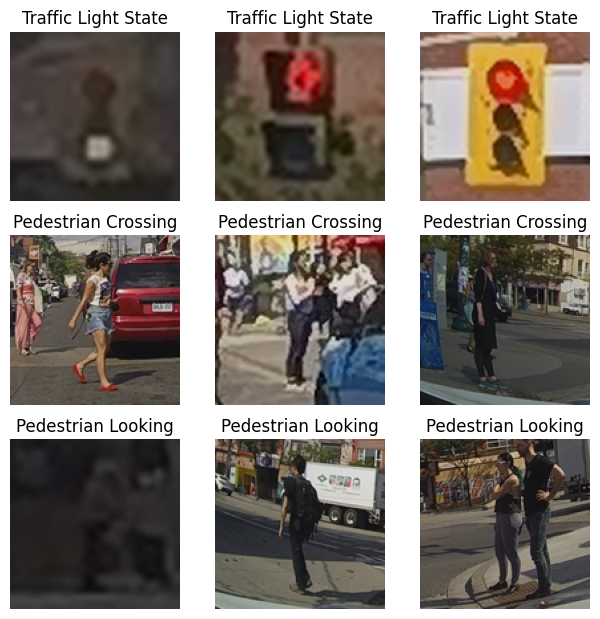

In [14]:
import matplotlib.pyplot as plt
from PIL import Image

examples_fail = {'Traffic light state': [], 'Pedestrian crossing': [], 'Pedestrian looking': []}
for image, test, pred in zip(images, y_test_, y_pred_):
    if image[0, 0, 3] == -1 and test[0] != pred[0] and pred[0] != 0:  # Traffic light state
        examples_fail['Traffic light state'].append((image[:, :, :3] * 225).astype(np.uint8))  
    if image[0, 0, 3] == 1 and test[1] != pred[1] and pred[1] != 0:  # Pedestrian crossing
        examples_fail['Pedestrian crossing'].append((image[:, :, :3] * 225).astype(np.uint8))
    if image[0, 0, 3] == 1 and test[2] != pred[2] and pred[2] != 0:  # Pedestrian looking
        examples_fail['Pedestrian looking'].append((image[:, :, :3] * 225).astype(np.uint8))

lights   = examples_fail['Traffic light state']
crossing = examples_fail['Pedestrian crossing']
looking  = examples_fail['Pedestrian looking']

np.random.shuffle(lights)
np.random.shuffle(crossing)
np.random.shuffle(looking)

fig, axes = plt.subplots(3, 3, figsize=(7.5, 7.5))
for i in range(3):
    light, cross, look = lights[i], crossing[i], looking[i]
    axes[0, i].imshow(light)
    axes[0, i].axis('off')
    axes[0, i].set_title('Traffic Light State')
    
    axes[1, i].imshow(cross)
    axes[1, i].axis('off')
    axes[1, i].set_title('Pedestrian Crossing')
    
    axes[2, i].imshow(look)
    axes[2, i].axis('off')
    axes[2, i].set_title('Pedestrian Looking')
    
    axes[2, i].imshow(look)
    axes[2, i].axis('off')
    axes[2, i].set_title('Pedestrian Looking')
    

In [ ]:
import pickle

# Save the model to a file
with open('pedestrian_behavior_or_trafficlight_state_cnn_model.pkl', 'wb') as f:
    pickle.dump(cnn_traffic_behaviour, f)

```python
# Load the model back into memory
with open('pedestrian_behavior_or_trafficlight_state_cnn_model.pkl', 'rb') as f:
    cnn_traffic_behaviour = pickle.load(f)
```